**NIFTY50 FEATURE ENGINEERING - OPEN PRICE**

In [1]:
# Numerical Computation and Data Manipulation
import numpy as np
import pandas as pd
import math

# Yahoo Finance API
import yfinance as yf

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Scaling and Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filter Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Configuration
tickers = {"Nifty 50": "^NSEI"}
horizons = {
    "5_Years": "2021-06-01",
    "10_Years": "2016-06-01",
    "20_Years": "2006-06-01"
}
end_date = "2026-06-01"

models = {
    "Naive Persistence": None,
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Elastic Net": ElasticNet(),
    "SGDRegressor": SGDRegressor(),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

In [3]:
def prep_engineered_data_for_open(raw_data):
    df = raw_data.copy()
    
    # 1. Feature Engineering
    # Trend: Simple Moving Averages
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    
    # Risk/Regime: Rolling Volatility (Standard Deviation of returns)
    df['Volatility_20'] = df['Close'].rolling(window=20).std()
    
    # Momentum: Daily Return percentage
    df['Daily_Return'] = df['Close'].pct_change()
    
    # Momentum: Relative Strength Index (RSI - 14 Day)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    # 2. Define Target 
    # Next Day's Open Price
    df["Target"] = df["Open"].shift(-1)
    
    # Define final columns to use
    feature_cols = [
        "Open", "High", "Low", "Close", "Volume", 
        "SMA_10", "SMA_20", "Volatility_20", "Daily_Return", "RSI_14"
    ]
        
    # Clean data (Drop NaNs generated by rolling windows and shift)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    clean_df = df[feature_cols + ["Target"]].dropna()
    
    X = clean_df[feature_cols]
    y = clean_df["Target"]
    
    return X, y

In [4]:

# Dictionaries to store results
train_results_dfs = {}
test_results_dfs = {}
plot_data_store = {} 

for company, ticker in tickers.items():
    print(f"Downloading data for: {company} ({ticker})")
    # Fetch extra historical data to accommodate the 20-day rolling windows
    raw_data = yf.download(ticker, start="2005-01-01", end=end_date, progress=False)
    
    for horizon_name, start_date in horizons.items():
        horizon_raw = raw_data.loc[start_date:end_date]
        
        # Prepare Engineered Data
        X, y = prep_engineered_data_for_open(horizon_raw)
        
        # Chronological Split (80/20)
        split = int(len(X) * 0.8)
        X_train, X_test = X.iloc[:split], X.iloc[split:]
        y_train, y_test = y.iloc[:split], y.iloc[split:]
        
        # Setup dictionary for plotting
        dict_key = (company, horizon_name)
        plot_data_store[dict_key] = {'y_test': y_test, 'predictions': {}}
        
        current_train_metrics = []
        current_test_metrics = []
        
        for model_name, model in models.items():
            if model_name == "Naive Persistence":
                # Naive Persistence uses the raw unscaled Open price directly (column index 0)
                train_pred = X_train.iloc[:, 0].values
                test_pred = X_test.iloc[:, 0].values
            else:
                # Build and train pipeline for ML models
                pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
                pipe.fit(X_train, y_train)
                
                # Predict
                train_pred = pipe.predict(X_train)
                test_pred = pipe.predict(X_test)
            
            # Save predictions for charts
            plot_data_store[dict_key]['predictions'][model_name] = test_pred
            
            # Store Metrics
            current_train_metrics.append({
                "Model": model_name,
                "Train_MAE": mean_absolute_error(y_train, train_pred),
                "Train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
                "Train_R2": r2_score(y_train, train_pred)
            })
            
            current_test_metrics.append({
                "Model": model_name,
                "Test_MAE": mean_absolute_error(y_test, test_pred),
                "Test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
                "Test_R2": r2_score(y_test, test_pred)
            })
            
        # Save dataframes sorted by Test R2
        train_results_dfs[(company, horizon_name)] = pd.DataFrame(current_train_metrics).sort_values(by="Train_R2", ascending=False, ignore_index=True)
        test_results_dfs[(company, horizon_name)] = pd.DataFrame(current_test_metrics).sort_values(by="Test_R2", ascending=False, ignore_index=True)

print("Execution Complete!")


Execution Complete!


In [5]:

# --- DISPLAY RESULTS ---
print("\n--- Train 5 Years (Engineered Open Price) ---")
display(train_results_dfs[("Nifty 50", "5_Years")])
print("\n--- Test 5 Years (Engineered Open Price) ---")
display(test_results_dfs[("Nifty 50", "5_Years")])

print("\n--- Train 10 Years (Engineered Open Price) ---")
display(train_results_dfs[("Nifty 50", "10_Years")])
print("\n--- Test 10 Years (Engineered Open Price) ---")
display(test_results_dfs[("Nifty 50", "10_Years")])

print("\n--- Train 20 Years (Engineered Open Price) ---")
display(train_results_dfs[("Nifty 50", "20_Years")])
print("\n--- Test 20 Years (Engineered Open Price) ---")
display(test_results_dfs[("Nifty 50", "20_Years")])



--- Train 5 Years (Engineered Open Price) ---


,Model,Train_MAE,Train_RMSE,Train_R2
0,DecisionTree,0.000000,0.000000,1.000000
1,XGBRegressor,5.775132,8.042477,0.999993
2,RandomForest,30.463881,45.665247,0.999764
3,GradientBoosting,48.939181,69.073680,0.999461
4,LinearRegression,69.797683,106.111644,0.998728
5,Ridge,75.569096,113.062296,0.998555
6,Lasso,79.695099,118.603850,0.998410
7,SGDRegressor,84.970690,122.841863,0.998295
8,Naive Persistence,136.255131,188.428193,0.995988
9,AdaBoostRegressor,175.407332,218.928444,0.994583



--- Test 5 Years (Engineered Open Price) ---


,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,90.960673,161.083619,0.965676
1,Ridge,105.382922,181.050364,0.956640
2,Lasso,108.259563,188.082582,0.953206
3,SGDRegressor,119.167305,193.954188,0.950239
4,RandomForest,130.973744,194.968450,0.949717
5,GradientBoosting,143.102387,209.113419,0.942157
6,Naive Persistence,165.795388,238.450831,0.924788
7,XGBRegressor,189.077755,260.718005,0.910085
8,DecisionTree,186.414609,267.373618,0.905436
9,AdaBoostRegressor,245.762838,322.403486,0.862504



--- Train 10 Years (Engineered Open Price) ---


...

,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,83.251947,145.235256,0.978265
1,Ridge,99.977465,164.474551,0.972125
2,SGDRegressor,118.580888,181.255317,0.966147
3,Lasso,122.504041,190.501868,0.962605
4,Naive Persistence,164.869999,234.988283,0.943101
5,Elastic Net,804.168009,831.467407,0.287635
6,GradientBoosting,1468.123115,1711.030278,-2.016667
7,RandomForest,1521.693320,1765.669451,-2.212409
8,DecisionTree,1543.726555,1785.922999,-2.286529
9,XGBRegressor,1741.490342,1980.117702,-3.040118



--- Train 20 Years (Engineered Open Price) ---


,Model,Train_MAE,Train_RMSE,Train_R2
0,DecisionTree,0.000000,0.000000,1.000000
1,XGBRegressor,15.027992,20.557939,0.999970
2,RandomForest,13.622774,24.404442,0.999958
3,GradientBoosting,32.954434,48.678198,0.999834
4,LinearRegression,31.619303,57.744906,0.999766
5,Ridge,35.883835,62.893658,0.999723
6,SGDRegressor,43.907426,72.642966,0.999630
7,Lasso,44.599044,76.244308,0.999593
8,Naive Persistence,73.652825,108.039485,0.999182
9,K-Nearest Neighbors,116.594607,165.520625,0.998080



--- Test 20 Years (Engineered Open Price) ---


,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,72.693948,122.980874,0.998159
1,Ridge,85.892910,137.632427,0.997694
2,SGDRegressor,102.231498,153.842211,0.997118
3,Lasso,114.671691,171.512777,0.996418
4,Naive Persistence,142.945362,204.003013,0.994933
5,Elastic Net,1321.953108,1362.158683,0.774091
6,RandomForest,3871.846920,4700.491060,-1.690074
7,DecisionTree,3877.892251,4702.059887,-1.691870
8,GradientBoosting,3889.556586,4718.527901,-1.710759
9,XGBRegressor,4088.457006,4913.199045,-1.939047


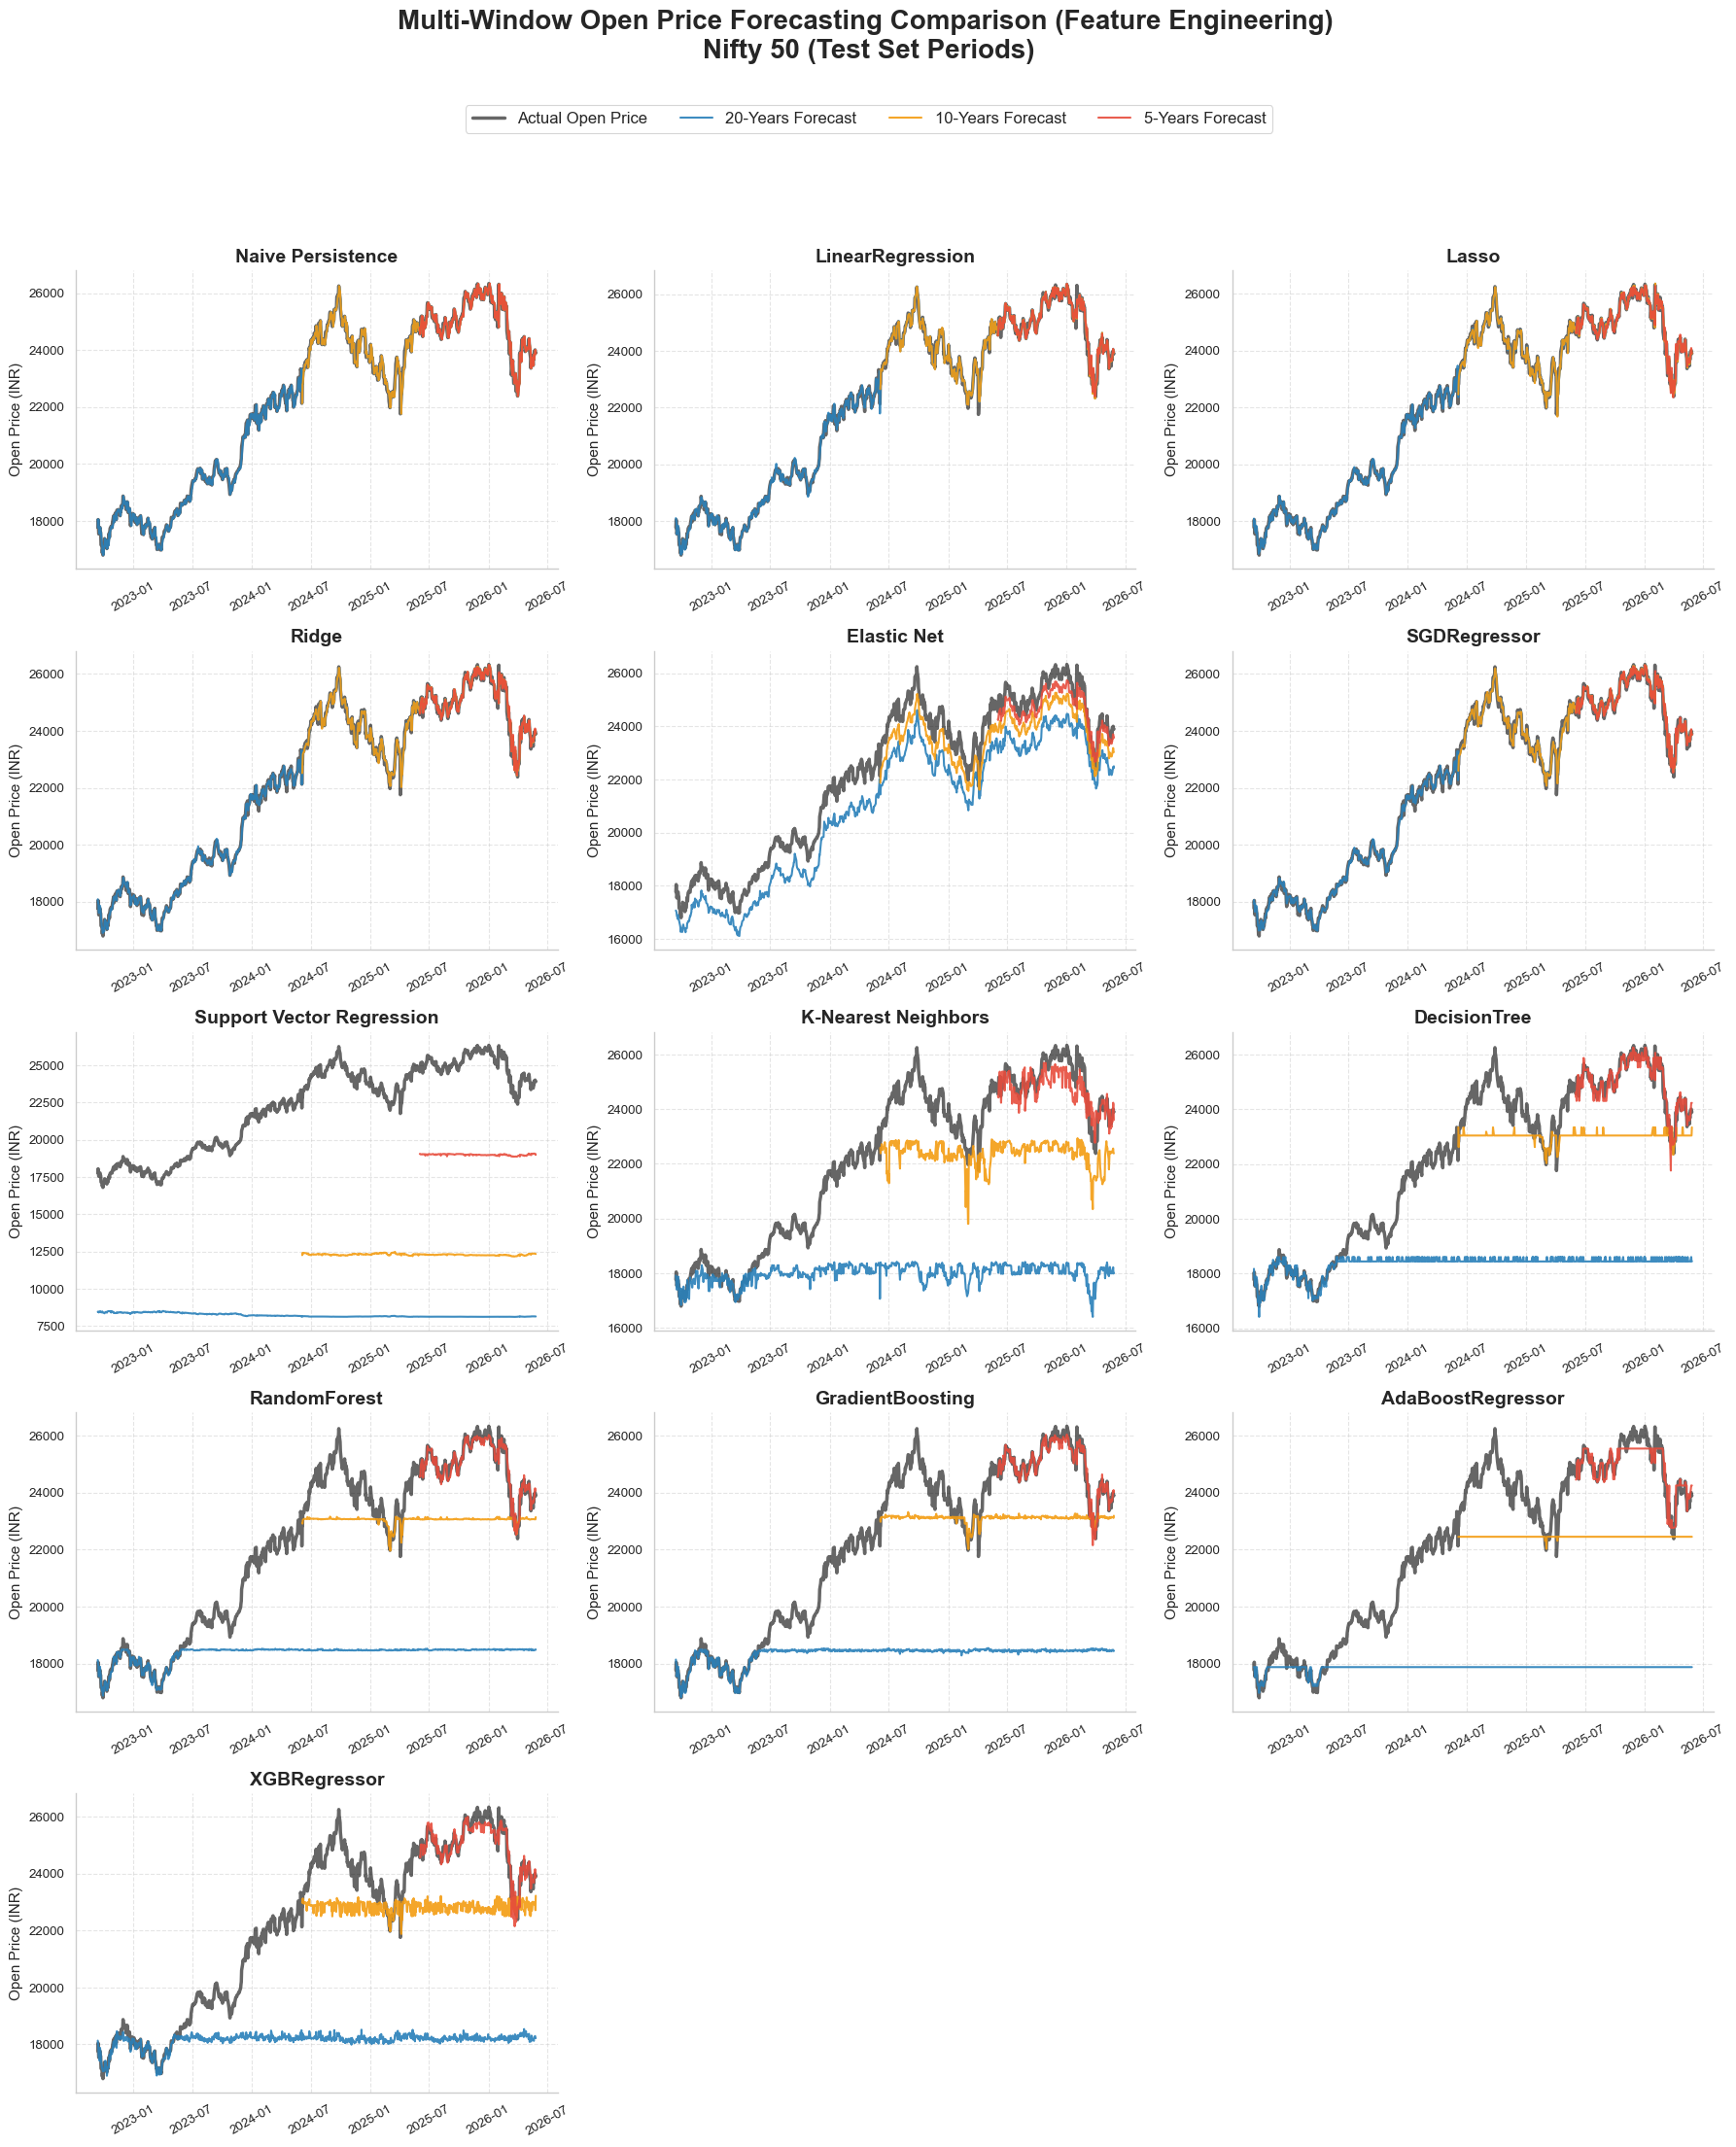

In [6]:
def plot_consolidated_predictions(company_name):
    """
    Plots Actual vs 5-Year, 10-Year, and 20-Year predictions 
    on a single graph for each model.
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    
    n_models = len(models)
    n_cols = 3 
    n_rows = math.ceil(n_models / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows), sharex=False)
    axes = axes.flatten()
    
    fig.suptitle(f"Multi-Window Open Price Forecasting Comparison (Feature Engineering) \n{company_name} (Test Set Periods)", 
                     fontsize=20, fontweight='bold', y=0.98)
    
    colors = {
        "5_Years": "#e74c3c",   
        "10_Years": "#f39c12", 
        "20_Years": "#2980b9"  
    }
    
    # Define the order (plot longest to shortest so shorter lines render on top)
    horizon_order = ["20_Years", "10_Years", "5_Years"]
    
    for i, model_name in enumerate(models.keys()):
        ax = axes[i]
        
        # 1. Plot the Actual Prices (Using the longest 20-year test set as the baseline)
        key_20 = (company_name, "20_Years")
        if key_20 in plot_data_store:
            y_actual_20 = plot_data_store[key_20]['y_test']
            ax.plot(y_actual_20.index, y_actual_20.values, color="black", 
                    linewidth=2.5, label="Actual Open Price", alpha=0.6)
            
        # 2. Loop through horizons and plot the predictions
        for horizon_name in horizon_order:
            key = (company_name, horizon_name)
            if key not in plot_data_store: 
                continue
                
            y_test = plot_data_store[key]['y_test']
            y_pred = plot_data_store[key]['predictions'][model_name]
            
            # Create a pandas Series to align the predictions with the real dates
            pred_series = pd.Series(y_pred, index=y_test.index)
            
            label_name = horizon_name.replace("_", "-") + " Forecast"
            ax.plot(pred_series.index, pred_series.values, color=colors[horizon_name], 
                    linewidth=1.5, label=label_name, alpha=0.9)
            
        # Formatting the subplot
        ax.set_title(f"{model_name}", fontsize=14, fontweight='bold')
        ax.set_ylabel("Open Price (INR)", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Make the x-axis dates readable
        ax.tick_params(axis='x', rotation=30)
        sns.despine(ax=ax)
        
    # Remove any empty subplots if the grid isn't perfectly filled
    for j in range(n_models, len(axes)): 
        fig.delaxes(axes[j])
        
    # Extract handles for a single master legend at the top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), 
               ncol=4, frameon=True, fontsize=12)
    
    # Adjust layout to make room for the master title and legend
    plt.tight_layout(rect=[0, 0, 1, 0.91])
    
    # Save the figure in high-res for your paper before showing it
    plt.savefig(f"{company_name}_open_baseline_engineered_performance_forecast.png", dpi=300, bbox_inches='tight')
    plt.show()

# Execute the visualization
plot_consolidated_predictions("Nifty 50")